# Debugging Particle Rotation
This notebook aims to figure out to correct rotation of particles in our micrographs.
The following steps are taken in this notebook:
1. Load particle and its associated micrograph
2. Plot the particle
3. Using the particle's location and its rotation, rotate the image of the particle
4. Using our pose restriction method, figure out Euler angles for the rotated particle (and display the rotated particle)
5. Check the Euler angle parametrization, convert to axis-angle, and convert back to Euler angles to ensure consistency

In [1]:
### Step 0: Import libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import random
import mrcfile
import pickle

from cryosparc.dataset import Dataset
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.spatial.transform import Rotation as R

import math
import numpy as np
import torch
import torch.nn.functional as F

### Step 1: Load particle and its associated micrograph

In [2]:
directory = '/Users/gerdbizi/Desktop/Rubinstein Lab/ryan_images/J3365/extract'
files = os.listdir(directory)

### Step 2: Plot the particle

In [3]:
random_file = random.choice(files)
print(random_file)
particle = mrcfile.open(directory + '/' + random_file, mode='r')
print(particle.data.shape)

# Pick a random idx from the particle
idx = random.randint(0, particle.data.shape[0] - 1)
particle = particle.data[idx]
print(particle.shape)


FoilHole_11264269_Data_10173110_10173112_20231011_222326_EER_patch_aligned_doseweighted_particles.mrc
(19, 500, 500)
(500, 500)


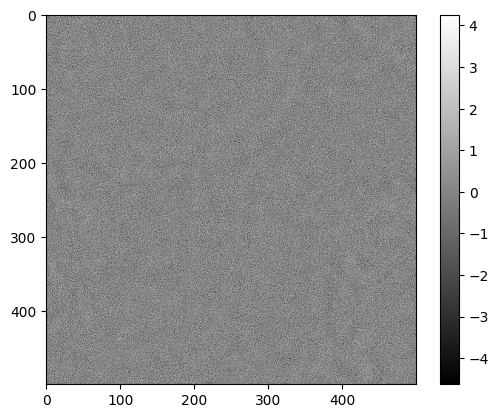

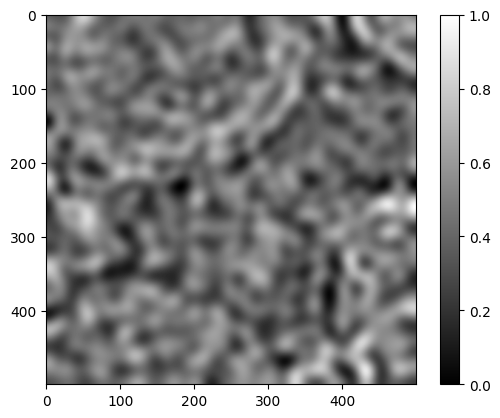

In [4]:
# Rotate particle 90 degrees counterclockwise
# particle = ndimage.rotate(particle, 90, reshape=False)

plt.imshow(particle, cmap='gray')
plt.colorbar()
plt.show()

# Apply gaussian lowpass filter and then sharpen
lowpass_filter = ndimage.gaussian_filter(particle, sigma=10)

# Apply sharpening using unsharp mask technique
sharpening_factor = 1 # Adjust this value to control sharpening intensity
blurred = ndimage.gaussian_filter(lowpass_filter, sigma=10)
sharpened = lowpass_filter + sharpening_factor * (lowpass_filter - blurred)

# Normalize the sharpened image to maintain proper intensity range
sharpened = (sharpened - sharpened.min()) / (sharpened.max() - sharpened.min())

# Display the lowpass filtered image
plt.imshow(sharpened, cmap='gray')
plt.colorbar()
plt.show()

### Step 3: Using the particle's location and its rotation, rotate the image of the particle

First, we need to load the cryosparc dataset and find the particle we're looking for
Then, we can extract the particle's rotation, shift, and position relative to the micrograph

In [5]:
cs_file = '/Users/gerdbizi/Desktop/Rubinstein Lab/ryan_images/J3365/extracted_particles.cs'
binarized_micrograph_path = '/Users/gerdbizi/Desktop/Rubinstein Lab/filtered_vesicles'
cs = Dataset.load(cs_file)
scaling_factor = 1024/4096 # Size of the binarized micrograph divided by the size of the original micrograph

In [6]:
print(cs) # Print the fields of the dataset

Dataset([  # 198766 items, 32 fields
    ('uid', [ 3594195723540814930 7824494210550147048 14101447717293291797 ... 17039687655059442827 2065012062762269259 1275955471049284477]),
    ('blob/path', ['J3365/extract/FoilHole_10169637_Data_10173120_10173122_20231010_104011_EER_patch_aligned_doseweighted_particles.mrc' 'J3365/extract/FoilHole_10169637_Data_10173120_10173122_20231010_104011_EER_patch_aligned_doseweighted_particles.mrc' 'J3365/extract/FoilHole_10169637_Data_10173120_10173122_20231010_104011_EER_patch_aligned_doseweighted_particles.mrc' ... 'J3365/extract/FoilHole_12287403_Data_10173110_10173112_20231012_124321_EER_patch_aligned_doseweighted_particles.mrc' 'J3365/extract/FoilHole_12287403_Data_10173110_10173112_20231012_124321_EER_patch_aligned_doseweighted_particles.mrc' 'J3365/extract/FoilHole_12287403_Data_10173110_10173112_20231012_124321_EER_patch_aligned_doseweighted_particles.mrc']),
    ('blob/idx', [0 1 2 ... 5 6 7]),
    ('blob/shape', [[500 500] [500 500] [500 500]

Here, we find the specific entry in the dataset that corresponds to the particle we're looking for

In [7]:
# Get the full path we're looking for
target_path = 'J3365/extract/' + random_file

# Create a query dictionary
query = {
    'blob/path': target_path,
    'blob/idx': idx
    }

# Use query_mask with the dictionary
mask = cs.query_mask(query)
matching_rows = cs.take(mask)

if len(matching_rows) > 0:
    # Get the first matching particle
    p = matching_rows[0]
    print("Found matching particle:")
    print(f"Path: {p['blob/path']}")
    print(f"Index: {p['blob/idx']}")
    print(f"Pose: {p['alignments3D/pose']}")
    print(f"Shift: {p['alignments3D/shift']}")
else:
    print(f"No particle found with path: {target_path} and idx: {idx}")

Found matching particle:
Path: J3365/extract/FoilHole_11264269_Data_10173110_10173112_20231011_222326_EER_patch_aligned_doseweighted_particles.mrc
Index: 11
Pose: [ 0.07363108  1.8477894  -1.7426022 ]
Shift: [ 0.1208334  -0.38749886]


### Step 4: Using our pose restriction method, figure out Euler angles for the rotated particle

Now, we'll use our pose restriction method.
First, for a given micrograph, figure out which vesicle the given particle belongs to (use distance to the center of the micrograph)
Then, for that vesicle, figure out the rotation of the particle around the centroid of the vesicle.

In [8]:
def percent_particle_in_vesicle(particle_box, vesicle_box):
    """
    Determine the percentage of the particle that is in the vesicle
    :param particle_box: The bounding box of the particle
    :param vesicle_box: The bounding box of the vesicle
    :return: The percentage of the particle that is in the vesicle
    """
    # print(particle_box, vesicle_box)
    particle_top_x, particle_top_y, particle_bottom_x, particle_bottom_y = particle_box
    vesicle_top_x, vesicle_top_y, vesicle_bottom_x, vesicle_bottom_y = vesicle_box

    particle_area = (particle_bottom_x - particle_top_x) * (particle_bottom_y - particle_top_y)

    # The area of the intersection of the particle and the vesicle
    intersection_area = max(0, min(particle_bottom_x, vesicle_bottom_x) - max(particle_top_x, vesicle_top_x)) * \
                        max(0, min(particle_bottom_y, vesicle_bottom_y) - max(particle_top_y, vesicle_top_y))

    return intersection_area / particle_area

In [9]:
def which_vesicle(x, y, shape_x, shape_y, micrograph):
    """
    Determine which vesicle the particle is in.
    :param x: The x coordinate of the particle
    :param y: The y coordinate of the particle
    :param micrograph: The micrograph
    :return: The vesicle ID
    """
    # plt.imshow(micrograph['composite_mask'])
    vesicle = None
    min_dist = np.inf

    particle_top_x = int(x - shape_x//2)
    particle_top_y = int(y - shape_y//2)
    particle_bottom_x = int(x + shape_x//2)
    particle_bottom_y = int(y + shape_y//2)
    particle_box = [particle_top_x, particle_top_y, particle_bottom_x, particle_bottom_y]
    # plt.gca().add_patch(plt.Rectangle((particle_top_x, particle_top_y), shape_x, shape_y, fill=False, edgecolor='green'))

    vesicle_top_x = None
    vesicle_top_y = None
    vesicle_bottom_x = None
    vesicle_bottom_y = None

    for entry in micrograph['masks']:
        vesicle_top_x = int(entry['bbox'][0])
        vesicle_top_y = int(entry['bbox'][1])
        vesicle_bottom_x_displace = int(entry['bbox'][2])
        vesicle_bottom_y_displace = int(entry['bbox'][3])
        middle_point_x = vesicle_top_x + vesicle_bottom_x_displace//2
        middle_point_y = vesicle_top_y + vesicle_bottom_y_displace//2
        
        # Calculate the distance between the particle and the middle point of the vesicle
        dist = math.sqrt((x - middle_point_x)**2 + (y - middle_point_y)**2)
        if dist < min_dist:
            min_dist = dist
            vesicle = entry

    # plt.show()

    return vesicle 

In [10]:
def get_centroid(vesicle):
    """
    Get the centroid of the vesicle via the centre of mass
    :param vesicle: The vesicle
    :return: The centroid of the vesicle in (x, y)
    """
    y, x = ndimage.measurements.center_of_mass(vesicle['segmentation'])
    return x, y

def get_alpha(reference_point, x, y):
    """
    Calculate angle from positive y-axis (clockwise positive) for a vector in image coordinates.
    Specifically designed for particle pose estimation in cryo-EM.
    
    Args:
        reference_point (tuple): (x,y) coordinates of particle centroid
        x (float): x-coordinate of target point (e.g., particle peak or feature)
        y (float): y-coordinate of target point
    
    Returns:
        float: Angle in radians, range [-π, π], clockwise positive from y-axis.
             Compatible with cryoSPARC pose conventions.
    """
    # Convert to vector from centroid
    dx = x - reference_point[0]
    # Invert dy for image coordinates (y increases downward)
    dy = -(y - reference_point[1])
    
    # Use atan2 to get angle from x-axis (standard mathematical angle)
    standard_angle = math.atan2(dy, dx)
    
    # Convert to our convention:
    # 1. Subtract π/2 to make 0° at positive y-axis
    alpha = standard_angle - math.pi/2
    
    # 2. Negate for clockwise positive convention
    alpha = -alpha
    
    # Normalize to [-π, π] range
    if alpha > math.pi:
        alpha -= 2*math.pi
    elif alpha < -math.pi:
        alpha += 2*math.pi
        
    return alpha

The following is some testing to see if the alpha angle is correct

In [11]:
origin = (0, 0)
test_points = [
    ((0, -1), 0),       # Vector pointing down (y-axis)
    ((1, 0), math.pi/2),  # Vector pointing right (x-axis)
    ((0, 1), math.pi),   # Vector pointing up (-y-axis)
    ((-1, 0), -math.pi/2) # Vector pointing left (-x-axis)
]

print("Running vector angle tests:")
for point, expected in test_points:
    angle = get_alpha(origin, point[0], point[1])
    print(f"Vector to {point}:")
    print(f"  Calculated angle: {angle:.4f} rad ({math.degrees(angle):.1f}°)")
    print(f"  Expected angle:   {expected:.4f} rad ({math.degrees(expected):.1f}°)")
    print(f"  Error: {abs(angle - expected):.6f} rad\n")

Running vector angle tests:
Vector to (0, -1):
  Calculated angle: -0.0000 rad (-0.0°)
  Expected angle:   0.0000 rad (0.0°)
  Error: 0.000000 rad

Vector to (1, 0):
  Calculated angle: 1.5708 rad (90.0°)
  Expected angle:   1.5708 rad (90.0°)
  Error: 0.000000 rad

Vector to (0, 1):
  Calculated angle: 3.1416 rad (180.0°)
  Expected angle:   3.1416 rad (180.0°)
  Error: 0.000000 rad

Vector to (-1, 0):
  Calculated angle: -1.5708 rad (-90.0°)
  Expected angle:   -1.5708 rad (-90.0°)
  Error: 0.000000 rad



Scaling factor: 0.25
Shape: 500, 500
Scaled shape: 125, 125
Micrograph shape: 4096, 4096
Scaled micrograph shape: 1024, 1024
Centre x frac: 0.8556834
Centre y frac: 0.20321961
Shift: 0.1208334, -0.38749886
Scaled shift: 0.030208349227905273, -0.09687471389770508
Unshifted loc x: 876
Unshifted loc y: 208
New loc x: 876
New loc y: 208


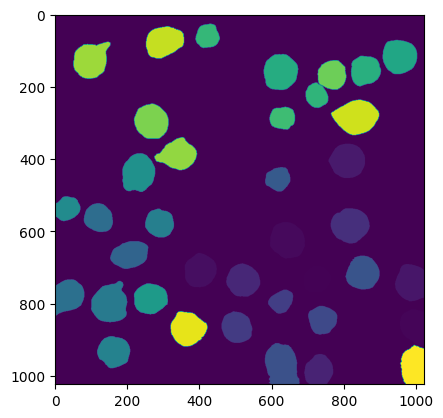

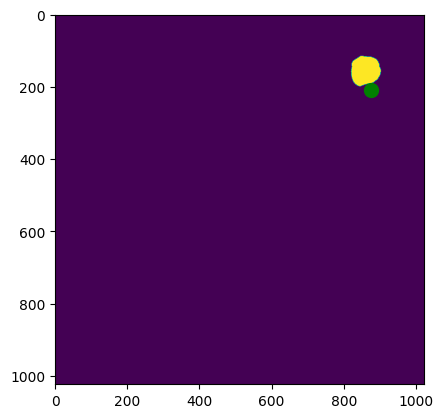

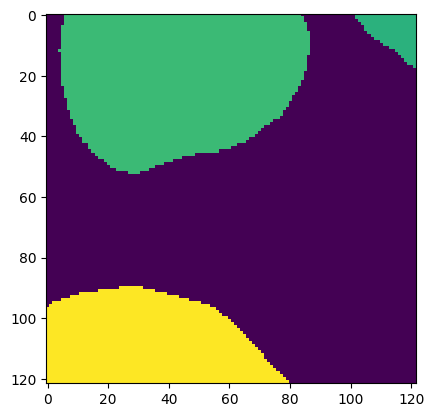

In [12]:
print("Scaling factor: " + str(scaling_factor))

shape_x, shape_y = p['blob/shape'] 
print("Shape: " + str(shape_x) + ", " + str(shape_y))

shape_x, shape_y = int(shape_x * scaling_factor), int(shape_y * scaling_factor)
print("Scaled shape: " + str(shape_x) + ", " + str(shape_y))
micrograph_uid = p['location/micrograph_uid']

mic_shape_x, mic_shape_y = p['location/micrograph_shape']
print("Micrograph shape: " + str(mic_shape_x) + ", " + str(mic_shape_y))

mic_shape_x, mic_shape_y = int(mic_shape_x * scaling_factor), int(mic_shape_y * scaling_factor)
print("Scaled micrograph shape: " + str(mic_shape_x) + ", " + str(mic_shape_y))

centre_x_frac = p['location/center_x_frac']
print("Centre x frac: " + str(centre_x_frac))

centre_y_frac = p['location/center_y_frac']
print("Centre y frac: " + str(centre_y_frac))

shift_x, shift_y = p['alignments3D/shift']
print("Shift: " + str(shift_x) + ", " + str(shift_y))

shift_x, shift_y = shift_x * scaling_factor, shift_y * scaling_factor
print("Scaled shift: " + str(shift_x) + ", " + str(shift_y))

# Calculate unshifted location
unshifted_loc_x = int(centre_x_frac * mic_shape_x)
print("Unshifted loc x: " + str(unshifted_loc_x))

unshifted_loc_y = int(centre_y_frac * mic_shape_y)
print("Unshifted loc y: " + str(unshifted_loc_y))

# Calculate new location
new_loc_x = int((centre_x_frac * mic_shape_x - shift_x))
print("New loc x: " + str(new_loc_x))

new_loc_y = int((centre_y_frac * mic_shape_y - shift_y))
print("New loc y: " + str(new_loc_y))

micrograph_id = f'/Users/gerdbizi/Desktop/Rubinstein Lab/filtered_vesicles/{micrograph_uid}_vesicles_filtered.pkl'
micrograph = lambda micrograph_id: pickle.load(open(micrograph_id, 'rb'))

# First, call the lambda function to get the micrograph data
micrograph_data = micrograph(micrograph_id)

plt.imshow(micrograph_data['composite_mask'])
plt.show()

# Find which vesicle the particle is in
vesicle = which_vesicle(new_loc_x, new_loc_y, shape_x, shape_y, micrograph_data)

# Now use the loaded data
prime_key_uint64 = np.uint64(vesicle['prime_key'])
segmentation_mask = (micrograph_data['composite_mask'] % prime_key_uint64) == 0
# del micrograph_data
vesicle['segmentation'] = segmentation_mask.astype(np.uint8)

# Plot the segmentation mask
plt.show()
plt.imshow(vesicle['segmentation'])

# Also plot the particle
plt.scatter(new_loc_x, new_loc_y, c='green', s=100)
plt.show()

# Now zoom in on the particle, with a 122x122 box around it
plt.imshow(micrograph_data['composite_mask'][new_loc_y - 61:new_loc_y + 61, new_loc_x - 61:new_loc_x + 61])
plt.show()


In [13]:
centroid = get_centroid(vesicle)
print(centroid)
print(new_loc_x, new_loc_y)
alpha = get_alpha(centroid, new_loc_x, new_loc_y)
print(alpha)

(858.3086828550405, 156.15618101545255)
876 208
2.81274077098384


/var/folders/hy/7f2mb4w14q56bjcr44s2483m0000gn/T/ipykernel_76586/639253142.py:7: DeprecationWarning: Please import `center_of_mass` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  y, x = ndimage.measurements.center_of_mass(vesicle['segmentation'])


The following creates a diagram of the particle, the vesicle, the vesicle's centroid, and the particle's location, along with demonstrating the correct rotation angle.

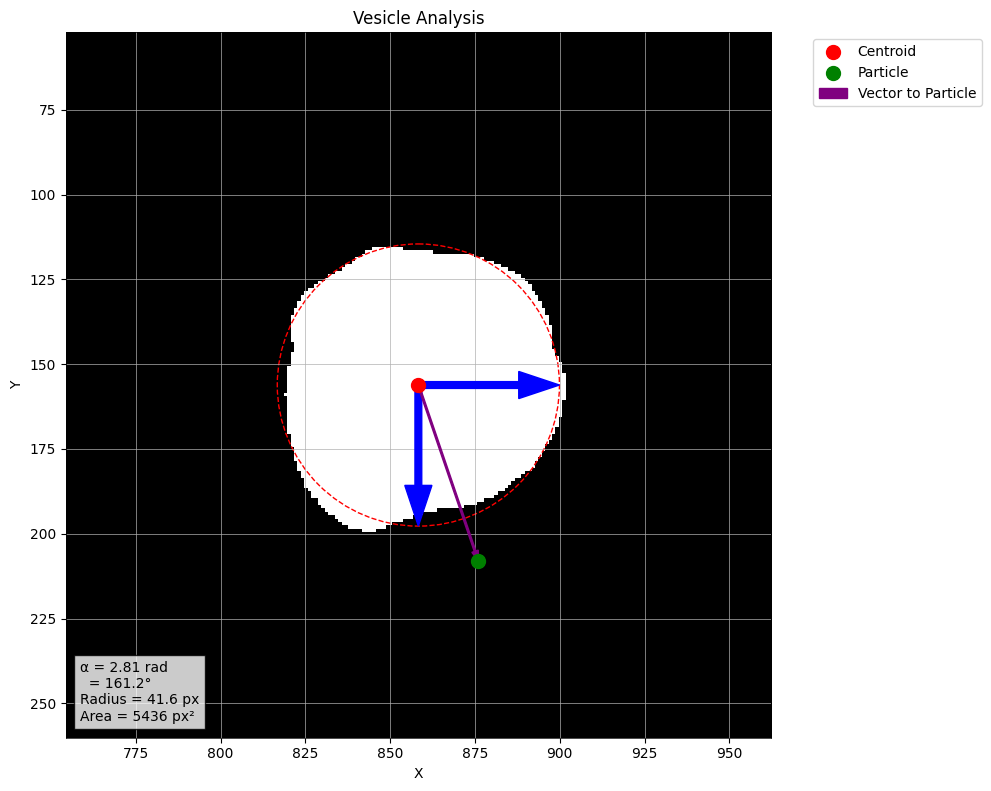

In [14]:
from scipy import ndimage

# Calculate vesicle area and radius
vesicle_mask = vesicle['segmentation'] > 0  # Create binary mask
area = ndimage.sum(vesicle_mask)  # Count number of pixels
radius = np.sqrt(area / np.pi)  # Calculate radius assuming circular shape

# Create figure with thinner axes
plt.figure(figsize=(10,10))
ax = plt.gca()
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# Plot vesicle segmentation
plt.imshow(vesicle['segmentation'], cmap='gray')


# Plot centroid (red dot)
plt.scatter(centroid[0], centroid[1], c='red', s=100, label='Centroid', zorder=4)

# Plot the particle (green dot)
plt.scatter(int(new_loc_x), int(new_loc_y), c='green', s=100, label='Particle', zorder=5)

# Draw line from centroid to particle (white arrow)
plt.arrow(centroid[0], centroid[1], 
         new_loc_x - centroid[0], new_loc_y - centroid[1],
         color='purple', width=0.5, head_width=2, length_includes_head=True,
         label='Vector to Particle', zorder=3)

# Draw reference angle lines
plt.arrow(centroid[0], centroid[1], radius, 0, 
         color='blue', width=2, head_width=8, length_includes_head=True, zorder=2)
plt.arrow(centroid[0], centroid[1], 0, radius,
         color='blue', width=2, head_width=8, length_includes_head=True, zorder=2)

# Add circle to show calculated radius
circle = plt.Circle(centroid, radius, fill=False, color='red', linestyle='--')
plt.gca().add_patch(circle)

# Set limits to zoom in around the vesicle
plt.xlim(centroid[0] - radius*2.5, centroid[0] + radius*2.5)
plt.ylim(centroid[1] + radius*2.5, centroid[1] - radius*2.5)

# Add labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vesicle Analysis')

# Move legend to upper right, outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add alpha angle and radius info to plot (moved to lower left)
plt.text(0.02, 0.02, 
         f'α = {alpha:.2f} rad\n  = {np.rad2deg(alpha):.1f}°\nRadius = {radius:.1f} px\nArea = {area} px²', 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8),
         verticalalignment='bottom')

plt.grid(True, linewidth=0.5)
plt.tight_layout()  # Adjust layout to prevent cutoff
plt.show()

(635, 635)


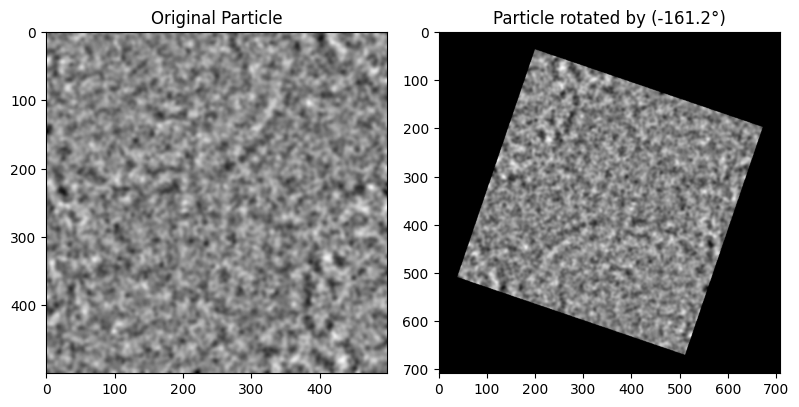

In [15]:
from scipy import ndimage

# Convert alpha from radians to degrees
alpha_deg = np.rad2deg(alpha)

# Create a mask of the same size as the particle (all ones)
mask = np.ones_like(particle)

# Apply low-pass filter (Gaussian blur)
sigma = 3.0  # Adjust this value to control blur amount
filtered_particle = ndimage.gaussian_filter(particle, sigma=sigma)

# # Mirror the particle left and right
# filtered_particle = np.fliplr(filtered_particle)

# Apply sharpening using unsharp mask technique
sharpening_factor = 1 # Adjust this value to control sharpening intensity
blurred = ndimage.gaussian_filter(filtered_particle, sigma=10)
sharpened = filtered_particle + sharpening_factor * (filtered_particle - blurred)

# Normalize the sharpened image to maintain proper intensity range
sharpened = (sharpened - sharpened.min()) / (sharpened.max() - sharpened.min())

# Rotate both the sharpened particle and the mask
rotated_particle = ndimage.rotate(sharpened, alpha_deg, reshape=True)
rotated_mask = ndimage.rotate(mask, alpha_deg, reshape=True)

# Create the final image
final_image = np.where(rotated_mask == 1, rotated_particle, 0.0)  # 1.0 for red regions
print(final_image.shape)

# pad the final image to be 710x710, keep the center of the image the same
final_image = np.pad(final_image, ((710 - final_image.shape[0])//2, (710 - final_image.shape[1])//2), mode='constant', constant_values=0.0)

# Display the original particle and the rotated particle side by side
plt.figure(figsize=(8, 8))

# Create a subplot with 1 row and 2 columns
plt.subplot(1, 2, 1)
plt.imshow(sharpened, cmap='gray')
plt.title('Original Particle')
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(final_image, cmap='gray')
plt.title(f'Particle rotated by ({-alpha_deg:.1f}°)')
plt.axis('on')

plt.tight_layout()
plt.show()

### Step 5: Angle conversion checking

This step is to check if the Euler angles we get from the pose restriction method are consistent with the Euler angles we get from the rotation matrix. We also do this to address the difficulties we had at the end of last semester with the Euler angle parametrizations.

The conversion functions are taken from: https://github.com/asarnow/pyem/blob/master/pyem/geom/convert.py

In [16]:
def rot2euler(r):
    """Decompose rotation matrix into Euler angles"""
    # assert(isrotation(r))
    # Shoemake rotation matrix decomposition algorithm with same conventions as Relion.
    epsilon = np.finfo(np.double).eps
    abs_sb = np.sqrt(r[0, 2] ** 2 + r[1, 2] ** 2)
    if abs_sb > 16 * epsilon:
        gamma = np.arctan2(r[1, 2], -r[0, 2])
        alpha = np.arctan2(r[2, 1], r[2, 0])
        if np.abs(np.sin(gamma)) < epsilon:
            sign_sb = np.sign(-r[0, 2]) / np.cos(gamma)
        else:
            sign_sb = np.sign(r[1, 2]) if np.sin(gamma) > 0 else -np.sign(r[1, 2])
        beta = np.arctan2(sign_sb * abs_sb, r[2, 2])
    else:
        if np.sign(r[2, 2]) > 0:
            alpha = 0
            beta = 0
            gamma = np.arctan2(-r[1, 0], r[0, 0])
        else:
            alpha = 0
            beta = np.pi
            gamma = np.arctan2(r[1, 0], -r[0, 0])
    return alpha, beta, gamma


def euler2rot(alpha, beta, gamma):
    ca = np.cos(alpha)
    cb = np.cos(beta)
    cg = np.cos(gamma)
    sa = np.sin(alpha)
    sb = np.sin(beta)
    sg = np.sin(gamma)
    cc = cb * ca
    cs = cb * sa
    sc = sb * ca
    ss = sb * sa
    r = np.array([[cg * cc - sg * sa, cg * cs + sg * ca, -cg * sb],
                  [-sg * cc - cg * sa, -sg * cs + cg * ca, sg * sb],
                  [sc, ss, cb]])
    return r


def vec2rot(v):
    ax = v / np.linalg.norm(v)
    return euler2rot(*np.array([np.arctan2(ax[1], ax[0]), np.arccos(ax[2]), 0.]))


def quat2aa(q):
    n = np.linalg.norm(q[1:])
    ax = q[1:] / n if n > 0 else np.zeros(3, dtype=q.dtype)
    theta = 2 * np.arctan2(n, q[0])  # Or 2 * np.arccos(q[0])
    return theta * ax


def aa2quat(ax, theta=None):
    if theta is None:
        theta = np.linalg.norm(ax)
        if theta != 0:
            ax = ax / theta
    q = np.zeros(4, dtype=ax.dtype)
    q[0] = np.cos(theta / 2)
    q[1:] = ax * np.sin(theta / 2)
    return q


def quat2rot(q):
    n = np.sum(q**2)
    s = 0 if n == 0 else 2 / n
    wx = s * q[0] * q[1]
    wy = s * q[0] * q[2]
    wz = s * q[0] * q[3]
    xx = s * q[1] * q[1]
    xy = s * q[1] * q[2]
    xz = s * q[1] * q[3]
    yy = s * q[2] * q[2]
    yz = s * q[2] * q[3]
    zz = s * q[3] * q[3]
    r = np.array([[1 - (yy + zz), xy + wz,       xz - wy],
                  [xy - wz,       1 - (xx + zz), yz + wx],
                  [xz + wy,       yz - wx,       1 - (xx + yy)]], dtype=q.dtype)
    return r


def rot2quat(r):
    q = np.zeros(4, dtype=r.dtype)
    tr = np.trace(r)
    if tr > 0:
        q[0] = np.sqrt(tr + 1) / 2
        sinv = 1 / (q[0] * 4)
        q[1] = sinv * (r[1, 2] - r[2, 1])
        q[2] = sinv * (r[2, 0] - r[0, 2])
        q[3] = sinv * (r[0, 1] - r[1, 0])
    else:
        mi = np.argmax(np.diag(r))
        if mi == 0:
            q[1] = np.sqrt(r[0, 0] - r[1, 1] - r[2, 2] + 1) / 2
            sinv = 1 / (q[1] * 4)
            q[0] = sinv * (r[1, 2] - r[2, 1])
            q[2] = sinv * (r[0, 1] + r[1, 0])
            q[3] = sinv * (r[0, 2] + r[2, 0])
        elif mi == 1:
            q[2] = np.sqrt(r[1, 1] - r[2, 2] - r[0, 0] + 1) / 2
            sinv = 1 / (q[2] * 4)
            q[0] = sinv * (r[2, 0] - r[0, 2])
            q[1] = sinv * (r[0, 1] + r[1, 0])
            q[3] = sinv * (r[1, 2] + r[2, 1])
        else:
            q[3] = np.sqrt(r[2, 2] - r[0, 0] - r[1, 1] + 1) / 2
            sinv = 1 / (q[3] * 4)
            q[0] = sinv * (r[0, 1] - r[1, 0])
            q[1] = sinv * (r[0, 2] + r[2, 0])
            q[2] = sinv * (r[1, 2] + r[2, 1])
    return q


def euler2quat(alpha, beta, gamma):
    ha, hb, hg = alpha / 2, beta / 2, gamma / 2
    ha_p_hg = ha + hg
    hg_m_ha = hg - ha
    q = np.array([np.cos(ha_p_hg) * np.cos(hb),
                  np.sin(hg_m_ha) * np.sin(hb),
                  np.cos(hg_m_ha) * np.sin(hb),
                  np.sin(ha_p_hg) * np.cos(hb)])
    return q


def quat2euler(q):
    ha1 = np.arctan2(q[1], q[2])
    ha2 = np.arctan2(q[3], q[0])
    alpha = ha2 - ha1  # np.arctan2(r21/r20)
    beta = 2 * np.arccos(np.sqrt(q[0]**2 + q[3]**2))  # np.arccos*r33
    gamma = ha1 + ha2  # np.arctan2(r12/-r02)
    return alpha, beta, gamma

In [21]:
print(p['alignments3D/pose'])
rotation_matrix = quat2rot(aa2quat((p['alignments3D/pose'])))
print(rotation_matrix)
euler_angles = [a for a in rot2euler(rotation_matrix)]
print(euler_angles)

[ 0.07363108  1.8477894  -1.7426022 ]
[[-0.8234382  -0.34914473 -0.44726655]
 [ 0.42605928  0.14012365 -0.89377785]
 [ 0.37473047 -0.9265329   0.0333732 ]]
[-1.186465, 1.537416925154984, -1.1068108]


In [18]:
euler_angles[1] = np.pi/2
euler_angles[2] = alpha + np.pi/2
# If the angle is greater than pi, subtract 2pi
if euler_angles[2] > np.pi:
    euler_angles[2] -= 2*np.pi
elif euler_angles[2] < -np.pi:
    euler_angles[2] += 2*np.pi
print(euler_angles)

[-1.186465, 1.5707963267948966, -1.8996482094008496]


Now, let's check our angle conversions.

In [20]:
phi = euler_angles[0]
theta = euler_angles[1]
psi = euler_angles[2]

print("Initial Euler angles (phi, theta, psi):")
print(f"α: {phi:.4f}, β: {theta:.4f}, γ: {psi:.4f}")

# Convert Euler to rotation matrix
R = euler2rot(phi, theta, psi)
print("\nRotation matrix:")
print(R)

# Get quaternion from rotation matrix
q = rot2quat(R)
print("\nQuaternion:")
print(q)

# Convert quaternion to axis-angle
aa = quat2aa(q)
print("\nAxis-angle:")
print(aa)

# Convert back to quaternion
q_back = aa2quat(aa)
print("\nQuaternion (recovered):")
print(q_back)

# Back to rotation matrix
R_back = quat2rot(q_back)
print("\nRotation matrix (recovered):")
print(R_back)

# Finally back to euler
phi_back, theta_back, psi_back = rot2euler(R_back)
print("\nRecovered Euler angles:")
print(f"phi: {phi_back:.4f}, theta: {theta_back:.4f}, psi: {psi_back:.4f}")

# Verify
print("\nDifferences:")
print(f"phi diff: {abs(phi - phi_back):.8f}")
print(f"theta diff: {abs(theta - theta_back):.8f}")
print(f"psi diff: {abs(psi - psi_back):.8f}")

# Also try the expmap function
expmap_version_R_back = expmap(aa)
print("\nExpmap version of rotation matrix (recovered):")
print(expmap_version_R_back)

# Also try the expmap function
expmap_version_R_back = expmap(aa)

Initial Euler angles (phi, theta, psi):
α: -1.1865, β: 1.5708, γ: -1.8996

Rotation matrix:
[[-8.77372250e-01 -3.54847734e-01  3.22956647e-01]
 [-2.99396746e-01 -1.21089147e-01 -9.46413759e-01]
 [ 3.74939322e-01 -9.27049339e-01  6.12323400e-17]]

Quaternion:
[-0.01961243  0.24683845 -0.66262416  0.70683474]

Axis-angle:
[ 0.78529974 -2.10809368  2.24874663]

Quaternion (recovered):
[-0.01961243  0.24683845 -0.66262416  0.70683474]

Rotation matrix (recovered):
[[-8.77372262e-01 -3.54847738e-01  3.22956647e-01]
 [-2.99396751e-01 -1.21089148e-01 -9.46413759e-01]
 [ 3.74939327e-01 -9.27049352e-01 -4.44089210e-16]]

Recovered Euler angles:
phi: -1.1865, theta: 1.5708, psi: -1.8996

Differences:
phi diff: 0.00000002
theta diff: 0.00000000
psi diff: 0.00000000


NameError: name 'expmap' is not defined

In [5564]:
def map_to_lie_algebra(v):
    """Map a point in R^N to the tangent space at the identity, i.e.
    to the Lie Algebra
    Arg:
        v = vector in R^N, (..., 3) in our case
    Return:
        R = v converted to Lie Algebra element, (3,3) in our case"""

    # make sure this is a sample from R^3
    assert v.size()[-1] == 3

    R_x = v.new_tensor([[0.0, 0.0, 0.0], [0.0, 0.0, -1.0], [0.0, 1.0, 0.0]])

    R_y = v.new_tensor([[0.0, 0.0, 1.0], [0.0, 0.0, 0.0], [-1.0, 0.0, 0.0]])

    R_z = v.new_tensor([[0.0, -1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 0.0]])

    R = (
        R_x * v[..., 0, None, None]
        + R_y * v[..., 1, None, None]
        + R_z * v[..., 2, None, None]
    )
    return R

def lietools_expmap(v):
    theta = v.norm(p=2, dim=-1, keepdim=True)
    # normalize K
    K = map_to_lie_algebra(v / theta)

    I = torch.eye(3, device=v.device, dtype=v.dtype)  # noqa: E741
    R = (
        I
        + torch.sin(theta)[..., None] * K
        + (1.0 - torch.cos(theta))[..., None] * (K @ K)
    )
    return R

expmap_version_R_back = lietools_expmap(torch.from_numpy(aa).float())
print(expmap_version_R_back)

tensor([[ 3.4874e-01,  9.3625e-01, -4.2668e-02],
        [-1.4894e-02, -3.9984e-02, -9.9909e-01],
        [-9.3710e-01,  3.4906e-01,  1.1921e-07]])
